# Walk-Forward Results Viewer

Visualize saved output from `python run_walk_forward.py`. This notebook does not run a backtest; it reads `data/results/walk_forward` and helps inspect stitched OOS performance plus fold-specific behavior.

In [15]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)

p = Path.cwd().resolve()
ROOT = p if (p / 'config.yaml').exists() and (p / 'src').exists() else next(
    (parent for parent in p.parents if (parent / 'config.yaml').exists() and (parent / 'src').exists()),
    p,
)
RESULTS_DIR = ROOT / 'data' / 'results' / 'walk_forward'
print('Project root:', ROOT)
print('Results dir: ', RESULTS_DIR)


Project root: C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner
Results dir:  C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner\data\results\walk_forward


## Load Results

In [16]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else {}

folds = read_csv_if_exists(RESULTS_DIR / 'walk_forward_folds.csv')
trades = read_csv_if_exists(RESULTS_DIR / 'walk_forward_trades.csv')
portfolio = read_csv_if_exists(RESULTS_DIR / 'walk_forward_portfolio.csv')
metrics = read_json_if_exists(RESULTS_DIR / 'walk_forward_metrics.json')
summary = read_json_if_exists(RESULTS_DIR / 'walk_forward_summary.json')
llm_overview = read_json_if_exists(RESULTS_DIR / 'llm_walk_forward_overview.json')

for col in ['train_start', 'train_end', 'test_start', 'test_end']:
    if col in folds.columns:
        folds[col] = pd.to_datetime(folds[col], errors='coerce')
for col in ['entry_date', 'exit_date']:
    if col in trades.columns:
        trades[col] = pd.to_datetime(trades[col], errors='coerce')
if 'date' in portfolio.columns:
    portfolio['date'] = pd.to_datetime(portfolio['date'], errors='coerce')

print(f'Folds:     {folds.shape}')
print(f'Trades:    {trades.shape}')
print(f'Portfolio: {portfolio.shape}')
print('LLM overview:', 'found' if llm_overview else 'not found yet - rerun walk-forward to generate it')


Folds:     (9, 48)
Trades:    (384, 27)
Portfolio: (2029, 8)
LLM overview: found


## Headline Metrics

In [17]:
summary_df = pd.DataFrame([{'metric': k, 'value': v} for k, v in summary.items()])
metrics_df = pd.DataFrame([{'metric': k, 'value': v} for k, v in metrics.items() if k != 'exit_reasons'])

display(Markdown('### Walk-Forward Summary'))
display(summary_df)
display(Markdown('### Stitched OOS Metrics'))
display(metrics_df)

if metrics.get('exit_reasons'):
    display(Markdown('### Exit Reasons'))
    display(pd.Series(metrics['exit_reasons'], name='count').sort_values(ascending=False).to_frame())


### Walk-Forward Summary

,metric,value
0,average_oos_sharpe,1.85
1,median_oos_sharpe,1.84
2,percentage_positive_oos_windows,88.89
3,percentage_positive_oos_trades,80.47
4,worst_oos_window_usd,0.00
5,stitched_max_drawdown_pct,-0.82
6,stitched_total_return_pct,16.65
7,total_runtime_sec,1413.75


### Stitched OOS Metrics

,metric,value
0,total_trades,384.00
1,win_rate_pct,80.50
2,avg_pnl_usd,43.37
3,avg_pnl_pct,14.24
4,median_pnl_usd,45.19
5,total_pnl_usd,16652.43
6,avg_win_usd,61.66
7,avg_loss_usd,-32.00
8,profit_factor,7.94
9,expectancy_usd,43.37


### Exit Reasons

,count
profit_target,321
normalization,56
walk_forward_fold_end,4
time_stop,2
stop_loss,1


## Fold Filters

Edit `SELECTED_FOLD` and rerun lower cells to focus fold-specific tables and charts.

In [18]:
SELECTED_FOLD = None  # Example: 3. None = all folds

filtered_folds = folds.copy()
filtered_trades = trades.copy()
filtered_portfolio = portfolio.copy()

if SELECTED_FOLD is not None:
    filtered_folds = filtered_folds[filtered_folds['fold'] == SELECTED_FOLD].copy()
    if 'fold' in filtered_trades.columns:
        filtered_trades = filtered_trades[filtered_trades['fold'] == SELECTED_FOLD].copy()
    if 'fold' in filtered_portfolio.columns:
        filtered_portfolio = filtered_portfolio[filtered_portfolio['fold'] == SELECTED_FOLD].copy()

print(f'Filtered folds: {len(filtered_folds):,} of {len(folds):,}')
print(f'Filtered trades: {len(filtered_trades):,} of {len(trades):,}')


Filtered folds: 9 of 9
Filtered trades: 384 of 384


## Fold Table

In [19]:
fold_cols = [
    'fold', 'train_start', 'train_end', 'test_start', 'test_end', 'selected_scenario',
    'number_of_trades', 'net_total_pnl_usd', 'oos_total_return_pct', 'oos_sharpe',
    'oos_max_drawdown_pct', 'oos_win_rate_pct', 'oos_profit_factor',
    'train_trades', 'train_sharpe', 'train_profit_factor', 'train_positive_subwindows',
    'selected_zscore_entry_min', 'selected_percentile_entry_min', 'selected_profit_target_pct',
    'selected_stop_loss_pct', 'selected_max_hold_days_param', 'selected_slippage_pct',
]
display(filtered_folds[[c for c in fold_cols if c in filtered_folds.columns]].reset_index(drop=True))


,fold,train_start,train_end,test_start,test_end,selected_scenario,number_of_trades,net_total_pnl_usd,oos_total_return_pct,oos_sharpe,oos_max_drawdown_pct,oos_win_rate_pct,oos_profit_factor,train_trades,train_sharpe,train_profit_factor,train_positive_subwindows,selected_zscore_entry_min,selected_percentile_entry_min,selected_profit_target_pct,selected_stop_loss_pct,selected_max_hold_days_param,selected_slippage_pct
0,1,2016-01-04,2018-01-03,2018-01-04,2019-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p15_mh30,59,3008.41,3.01,2.93,-0.50,81.4,8.53,110,2.37,9.66,3,0.5,75,0.150,-0.3,30,0.03
1,2,2016-01-04,2019-01-03,2019-01-04,2020-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p125_...,54,2083.54,2.02,1.70,-0.40,70.4,5.89,181,2.21,7.46,3,0.5,75,0.125,-0.3,30,0.03
2,3,2016-01-04,2020-01-03,2020-01-04,2021-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p125_...,16,1059.55,1.01,1.56,-0.27,100.0,inf,235,2.08,7.06,3,0.5,75,0.125,-0.3,30,0.03
3,4,2016-01-04,2021-01-03,2021-01-04,2022-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p125_...,56,2984.23,2.81,2.94,-0.39,94.6,11.77,251,1.98,7.71,3,0.5,75,0.125,-0.3,30,0.03
4,5,2016-01-04,2022-01-03,2022-01-04,2023-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,14,914.39,0.84,1.17,-0.17,92.9,86.56,329,1.71,6.63,3,0.5,75,0.100,-0.3,30,0.03
5,6,2016-01-04,2023-01-03,2023-01-04,2024-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,73,1749.50,1.59,1.84,-0.39,72.6,3.49,343,1.64,7.10,3,0.5,75,0.100,-0.3,30,0.03
6,7,2016-01-04,2024-01-03,2024-01-04,2025-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,85,3789.20,3.39,2.44,-0.82,81.2,9.36,412,1.69,6.91,3,0.5,75,0.100,-0.3,30,0.03
7,8,2016-01-04,2025-01-03,2025-01-04,2026-01-03,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,27,1063.61,0.92,2.05,-0.26,70.4,9.07,497,1.78,7.25,3,0.5,75,0.100,-0.3,30,0.03
8,9,2016-01-04,2026-01-03,2026-01-04,2026-01-30,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,0,0.00,0.00,0.00,0.00,0.0,0.00,524,1.77,7.35,3,0.5,75,0.100,-0.3,30,0.03


## Stitched Equity And Drawdown

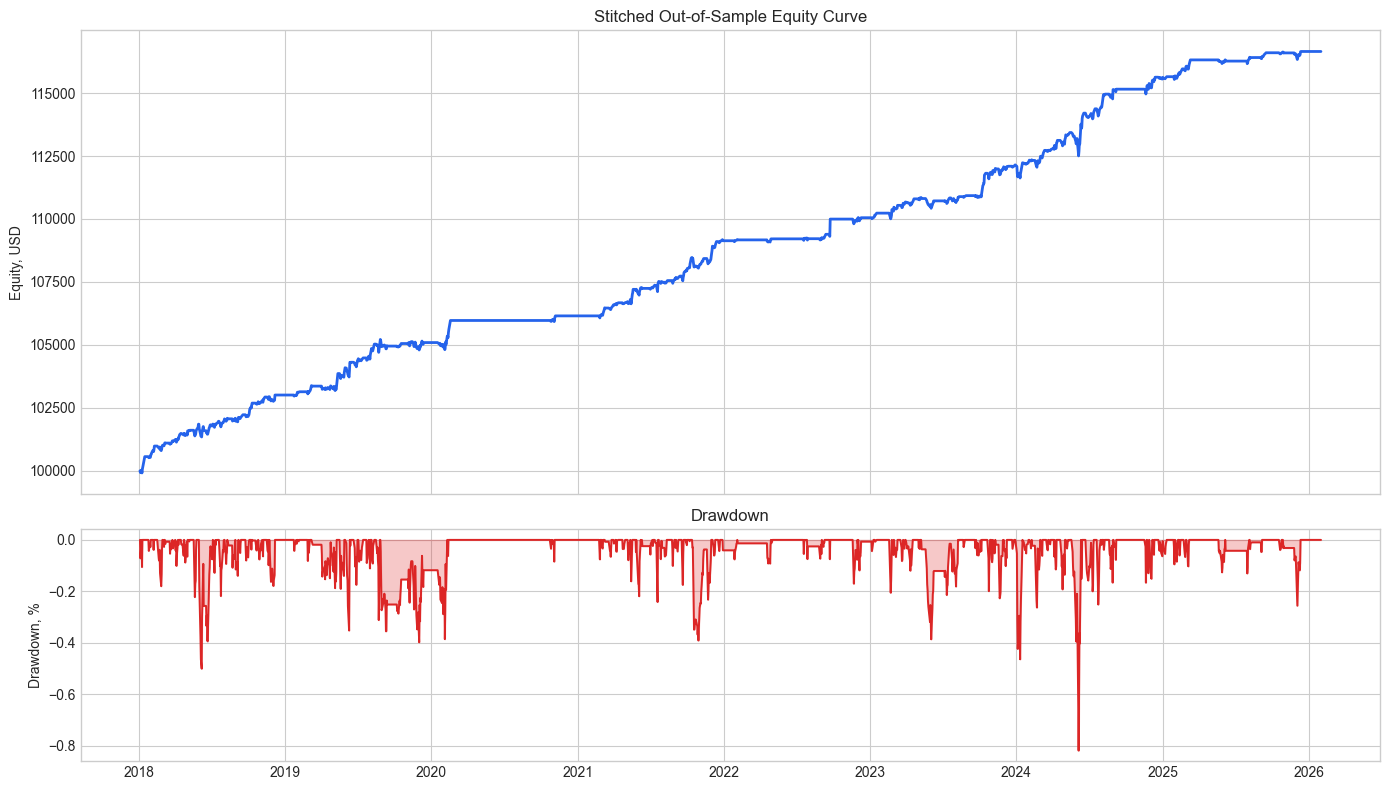

In [20]:
if filtered_portfolio.empty:
    print('No portfolio rows found.')
else:
    p = filtered_portfolio.sort_values('date').copy()
    p['drawdown_pct'] = (p['equity'] / p['equity'].cummax() - 1.0) * 100
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].plot(p['date'], p['equity'], linewidth=2, color='#2563eb')
    axes[0].set_title('Stitched Out-of-Sample Equity Curve' if SELECTED_FOLD is None else f'Fold {SELECTED_FOLD} OOS Equity Curve')
    axes[0].set_ylabel('Equity, USD')
    axes[1].fill_between(p['date'], p['drawdown_pct'], 0, color='#dc2626', alpha=0.25)
    axes[1].plot(p['date'], p['drawdown_pct'], color='#dc2626', linewidth=1.4)
    axes[1].set_title('Drawdown')
    axes[1].set_ylabel('Drawdown, %')
    plt.tight_layout()
    plt.show()


## Fold Performance Dashboard

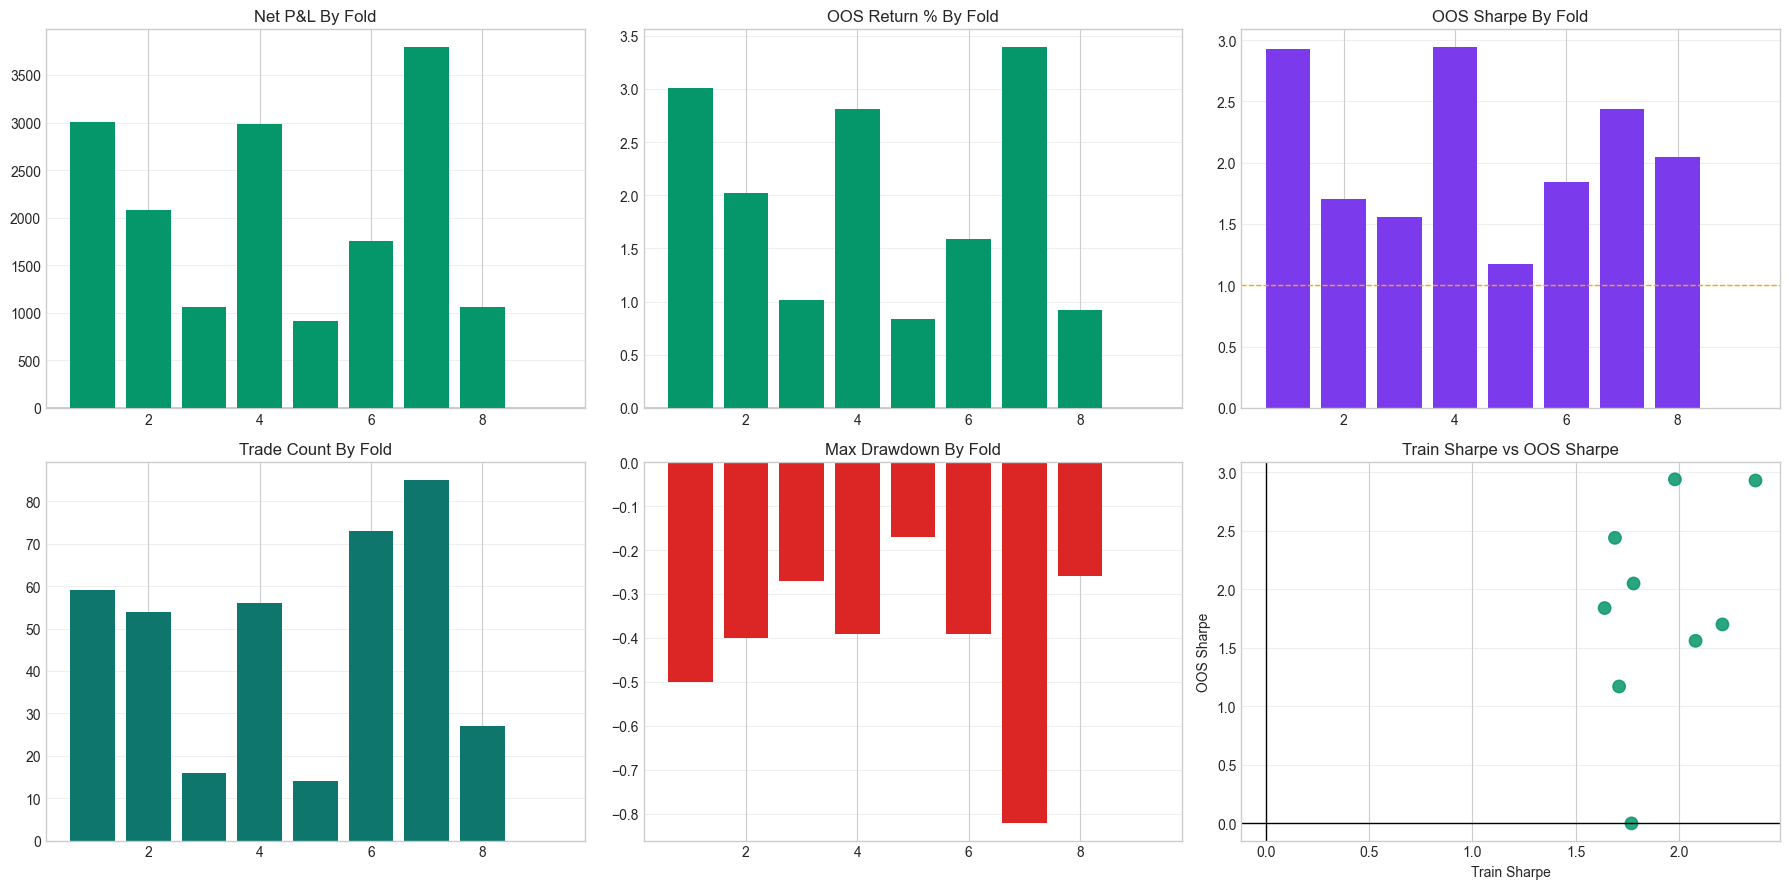

In [21]:
if folds.empty:
    print('No fold rows found.')
else:
    f = folds.sort_values('fold').copy()
    colors = np.where(f['net_total_pnl_usd'] >= 0, '#059669', '#dc2626')
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes[0, 0].bar(f['fold'], f['net_total_pnl_usd'], color=colors)
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title('Net P&L By Fold')
    axes[0, 1].bar(f['fold'], f['oos_total_return_pct'], color=colors)
    axes[0, 1].axhline(0, color='black', linewidth=1)
    axes[0, 1].set_title('OOS Return % By Fold')
    axes[0, 2].bar(f['fold'], f['oos_sharpe'], color='#7c3aed')
    axes[0, 2].axhline(1.0, color='orange', linestyle='--', linewidth=1)
    axes[0, 2].set_title('OOS Sharpe By Fold')
    axes[1, 0].bar(f['fold'], f['number_of_trades'], color='#0f766e')
    axes[1, 0].set_title('Trade Count By Fold')
    axes[1, 1].bar(f['fold'], f['oos_max_drawdown_pct'], color='#dc2626')
    axes[1, 1].set_title('Max Drawdown By Fold')
    axes[1, 2].scatter(f['train_sharpe'], f['oos_sharpe'], c=colors, s=80, alpha=0.85)
    axes[1, 2].axhline(0, color='black', linewidth=1)
    axes[1, 2].axvline(0, color='black', linewidth=1)
    axes[1, 2].set_title('Train Sharpe vs OOS Sharpe')
    axes[1, 2].set_xlabel('Train Sharpe')
    axes[1, 2].set_ylabel('OOS Sharpe')
    for ax in axes.ravel():
        ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## Trades Per Year

,trades,total_pnl,avg_pnl,win_rate,avg_hold_days
year,,,,,
2018,59,3008.41,50.99,81.36,9.80
2019,54,2083.54,38.58,70.37,10.07
2020,16,1059.55,66.22,100.00,8.06
2021,56,2984.23,53.29,94.64,8.14
2022,14,914.39,65.31,92.86,9.14
2023,69,2044.80,29.63,75.36,8.19
2024,88,3535.88,40.18,79.55,7.58
2025,28,1021.62,36.49,67.86,6.82


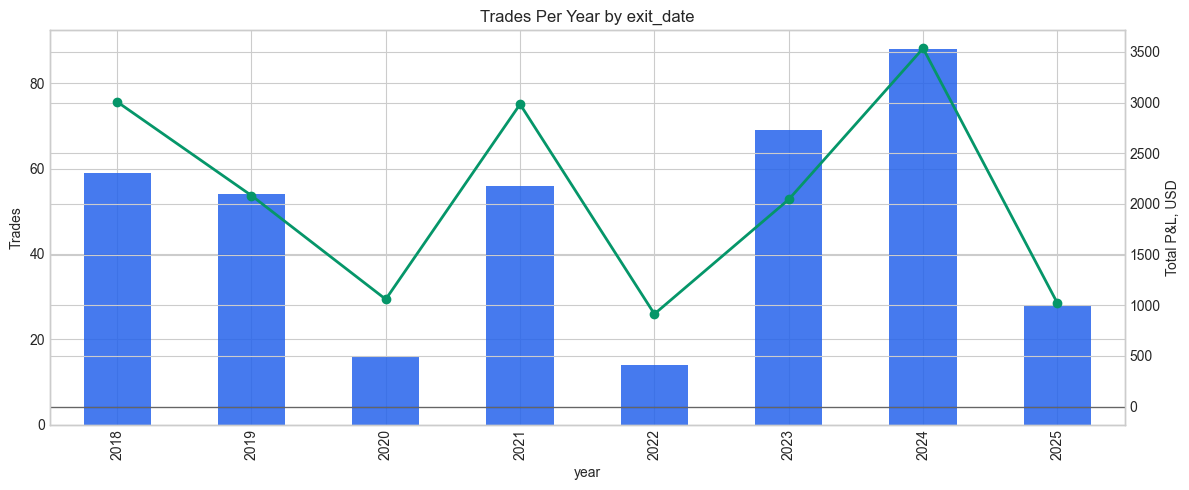

In [22]:
if filtered_trades.empty:
    print('No trades found.')
else:
    t = filtered_trades.copy()
    date_col = 'exit_date' if 'exit_date' in t.columns else 'entry_date'
    t[date_col] = pd.to_datetime(t[date_col], errors='coerce')
    t = t.dropna(subset=[date_col])
    t['year'] = t[date_col].dt.year
    trades_per_year = t.groupby('year').agg(
        trades=('pnl', 'size'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        win_rate=('pnl', lambda s: (s > 0).mean() * 100),
        avg_hold_days=('hold_days', 'mean'),
    ).round(2)
    display(trades_per_year)
    fig, ax1 = plt.subplots(figsize=(12, 5))
    trades_per_year['trades'].plot(kind='bar', ax=ax1, color='#2563eb', alpha=0.85)
    ax1.set_title(f'Trades Per Year by {date_col}')
    ax1.set_ylabel('Trades')
    ax2 = ax1.twinx()
    ax2.plot(range(len(trades_per_year.index)), trades_per_year['total_pnl'], color='#059669', marker='o', linewidth=2)
    ax2.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax2.set_ylabel('Total P&L, USD')
    plt.tight_layout()
    plt.show()


## Scenario And Parameter Selection Stability

,selected_scenario,folds_selected,trades,net_pnl,avg_oos_sharpe,avg_oos_return_pct
2,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p1_mh30,5,199,7516.70,1.500000,1.348000
0,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p125_...,3,126,6127.32,2.066667,1.946667
1,z0p5_pct75_biv70_rv1p0_relaxed_dc0p06_pt0p15_mh30,1,59,3008.41,2.930000,3.010000


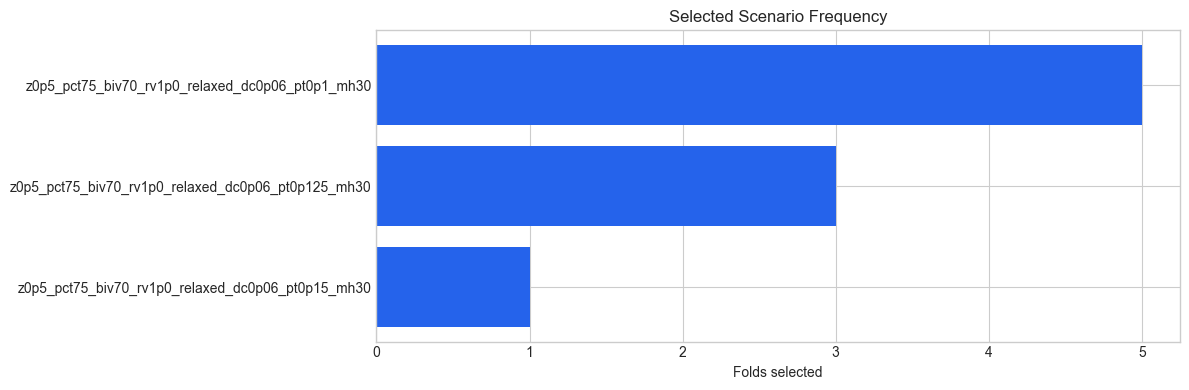

### Selected Parameter Values By Fold

,fold,selected_zscore_entry_min,selected_percentile_entry_min,selected_back_iv_percentile_max,selected_rv_iv_ratio_max,selected_max_debit_pct_of_spot,selected_profit_target_pct,selected_stop_loss_pct,selected_max_hold_days_param,selected_slippage_pct
0,1,0.5,75,70,1.0,0.06,0.150,-0.3,30,0.03
1,2,0.5,75,70,1.0,0.06,0.125,-0.3,30,0.03
2,3,0.5,75,70,1.0,0.06,0.125,-0.3,30,0.03
3,4,0.5,75,70,1.0,0.06,0.125,-0.3,30,0.03
4,5,0.5,75,70,1.0,0.06,0.100,-0.3,30,0.03
5,6,0.5,75,70,1.0,0.06,0.100,-0.3,30,0.03
6,7,0.5,75,70,1.0,0.06,0.100,-0.3,30,0.03
7,8,0.5,75,70,1.0,0.06,0.100,-0.3,30,0.03
8,9,0.5,75,70,1.0,0.06,0.100,-0.3,30,0.03


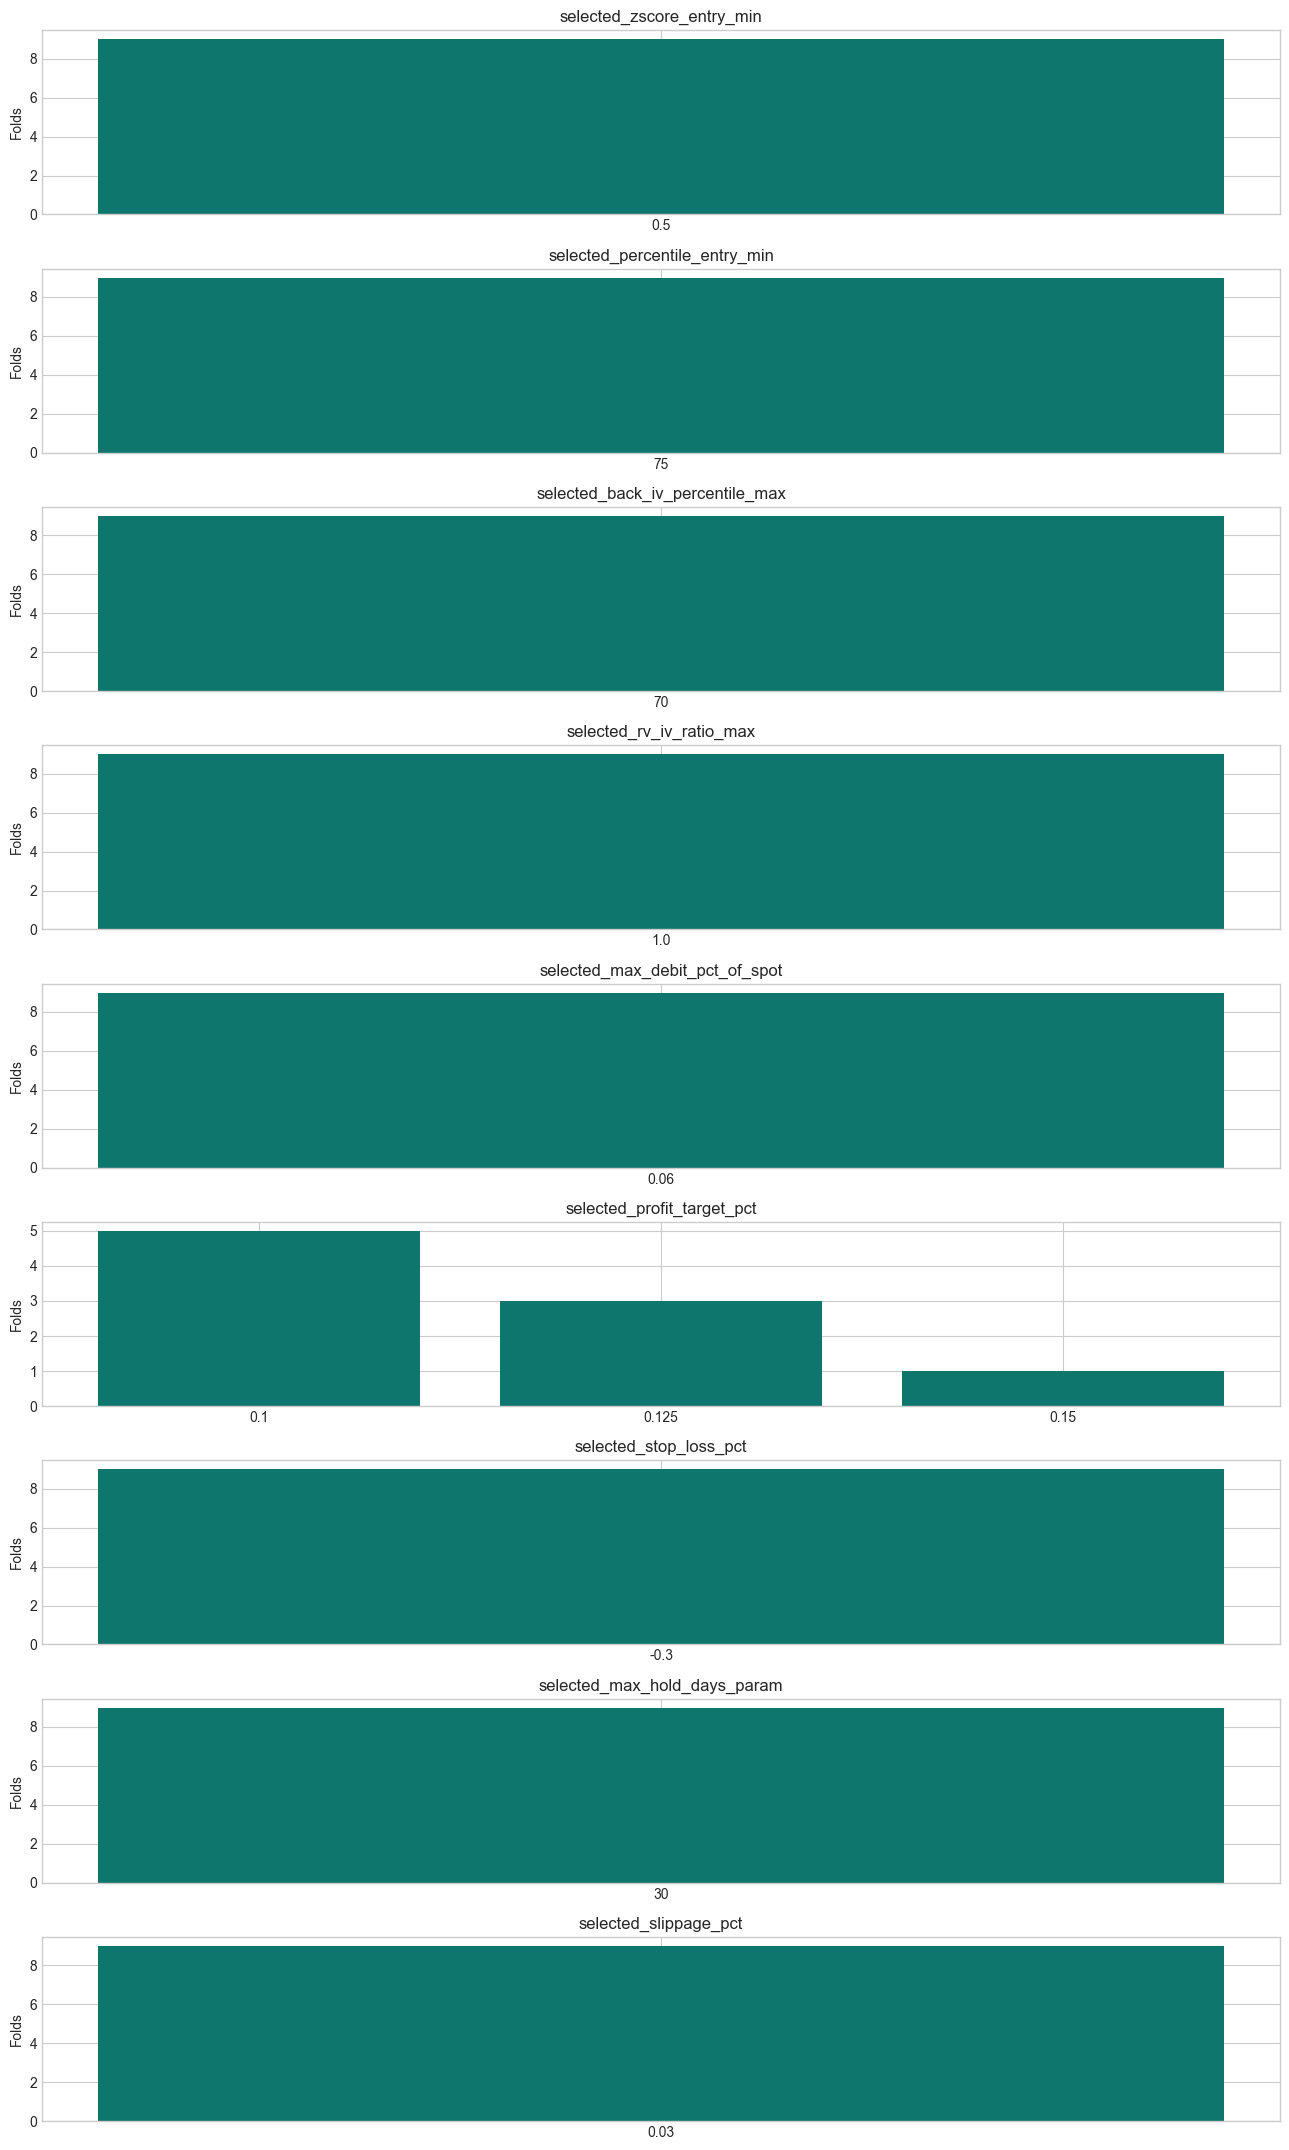

In [23]:
if folds.empty or 'selected_scenario' not in folds.columns:
    print('No selected scenario data found.')
else:
    scenario_summary = folds.groupby('selected_scenario', as_index=False).agg(
        folds_selected=('fold', 'count'),
        trades=('number_of_trades', 'sum'),
        net_pnl=('net_total_pnl_usd', 'sum'),
        avg_oos_sharpe=('oos_sharpe', 'mean'),
        avg_oos_return_pct=('oos_total_return_pct', 'mean'),
    ).sort_values(['folds_selected', 'net_pnl'], ascending=[False, False])
    display(scenario_summary)

    top = scenario_summary.head(20).sort_values('folds_selected')
    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(top))))
    ax.barh(top['selected_scenario'], top['folds_selected'], color='#2563eb')
    ax.set_title('Selected Scenario Frequency')
    ax.set_xlabel('Folds selected')
    plt.tight_layout()
    plt.show()

param_cols = [c for c in folds.columns if c.startswith('selected_') and c != 'selected_scenario']
if param_cols:
    display(Markdown('### Selected Parameter Values By Fold'))
    display(folds[['fold', *param_cols]].reset_index(drop=True))
    n = len(param_cols)
    fig, axes = plt.subplots(n, 1, figsize=(13, max(3, 2.4 * n)), squeeze=False)
    for ax, col in zip(axes.ravel(), param_cols):
        counts = folds[col].value_counts(dropna=False).sort_index()
        ax.bar(counts.index.astype(str), counts.values, color='#0f766e')
        ax.set_title(col)
        ax.set_ylabel('Folds')
    plt.tight_layout()
    plt.show()
else:
    print('Selected parameter columns are not present. Rerun walk-forward with the latest code to populate them.')


## Trade Distribution And Cumulative P&L

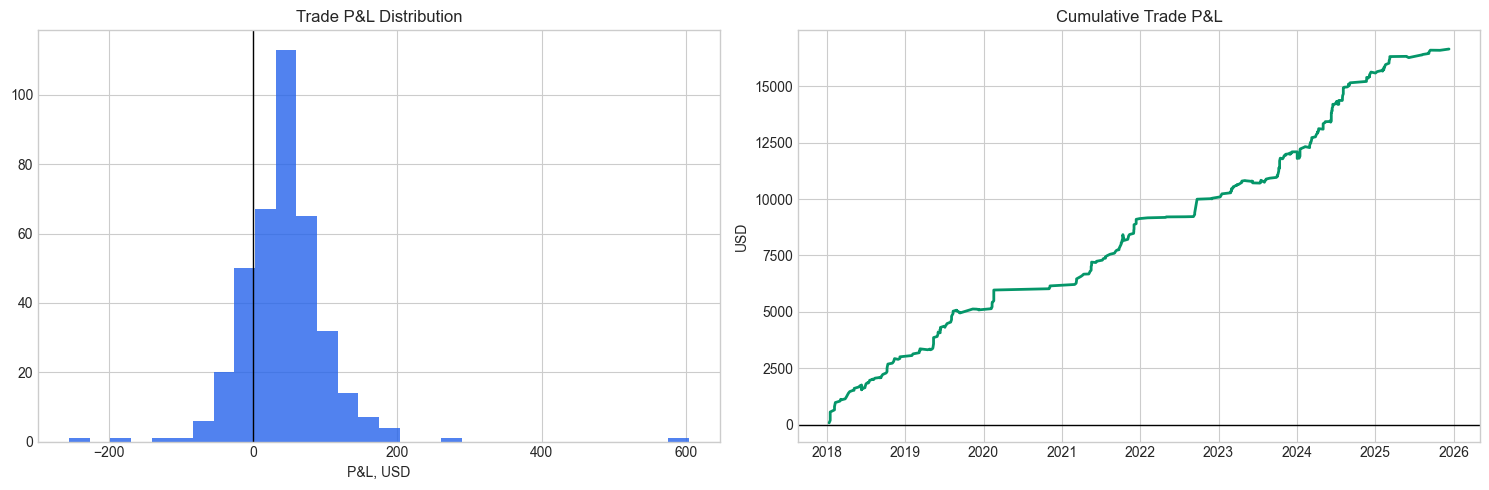

In [24]:
if filtered_trades.empty:
    print('No trades found.')
else:
    t = filtered_trades.sort_values('exit_date').copy()
    t['cum_pnl'] = t['pnl'].cumsum()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(t['pnl'], bins=30, color='#2563eb', alpha=0.8)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_title('Trade P&L Distribution')
    axes[0].set_xlabel('P&L, USD')
    axes[1].plot(t['exit_date'], t['cum_pnl'], color='#059669', linewidth=2)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Cumulative Trade P&L')
    axes[1].set_ylabel('USD')
    plt.tight_layout()
    plt.show()


## Ticker And Exit Breakdown

,trades,total_pnl,avg_pnl,win_rate,avg_hold_days
ticker,,,,,
TLT,68,3860.36,56.77,94.12,7.78
GLD,56,3278.04,58.54,87.50,8.71
IWM,38,2208.28,58.11,94.74,7.89
QQQ,26,1683.36,64.74,92.31,7.12
EEM,45,1585.16,35.23,57.78,9.18
XLE,32,1453.98,45.44,90.62,8.38
SPY,35,1409.64,40.28,88.57,9.54
EFA,39,1116.42,28.63,71.79,9.72
XLF,45,57.20,1.27,48.89,8.04


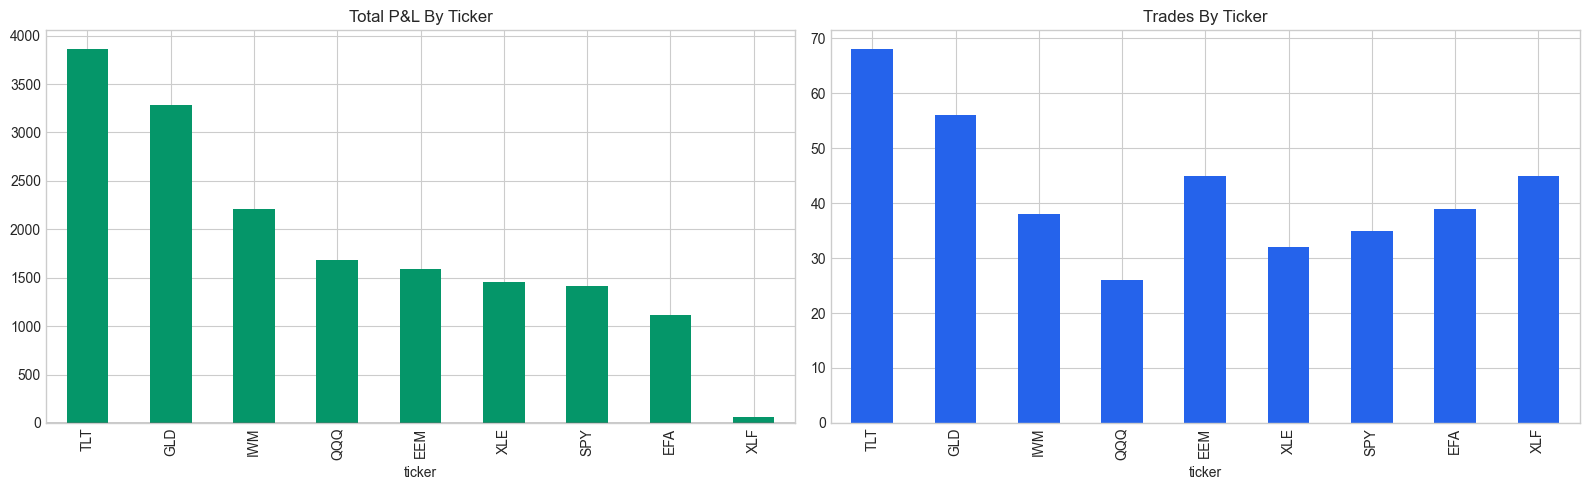

### Exit Reason Summary

,trades,total_pnl,avg_pnl,win_rate,avg_hold_days
exit_reason,,,,,
profit_target,321,18174.89,56.62,90.34,7.65
normalization,56,-757.86,-13.53,32.14,13.11
walk_forward_fold_end,4,-295.30,-73.83,25.00,3.25
time_stop,2,-214.15,-107.08,0.00,22.00
stop_loss,1,-255.14,-255.14,0.00,12.00


In [25]:
if filtered_trades.empty:
    print('No trades found.')
else:
    by_ticker = filtered_trades.groupby('ticker').agg(
        trades=('pnl', 'size'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        win_rate=('pnl', lambda s: (s > 0).mean() * 100),
        avg_hold_days=('hold_days', 'mean'),
    ).sort_values('total_pnl', ascending=False).round(2)
    display(by_ticker)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    by_ticker['total_pnl'].plot(kind='bar', ax=axes[0], color=np.where(by_ticker['total_pnl'] >= 0, '#059669', '#dc2626'))
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Total P&L By Ticker')
    by_ticker['trades'].plot(kind='bar', ax=axes[1], color='#2563eb')
    axes[1].set_title('Trades By Ticker')
    plt.tight_layout()
    plt.show()

    exit_summary = filtered_trades.groupby('exit_reason').agg(
        trades=('pnl', 'size'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        win_rate=('pnl', lambda s: (s > 0).mean() * 100),
        avg_hold_days=('hold_days', 'mean'),
    ).sort_values('trades', ascending=False).round(2)
    display(Markdown('### Exit Reason Summary'))
    display(exit_summary)


## Monthly P&L Heatmap

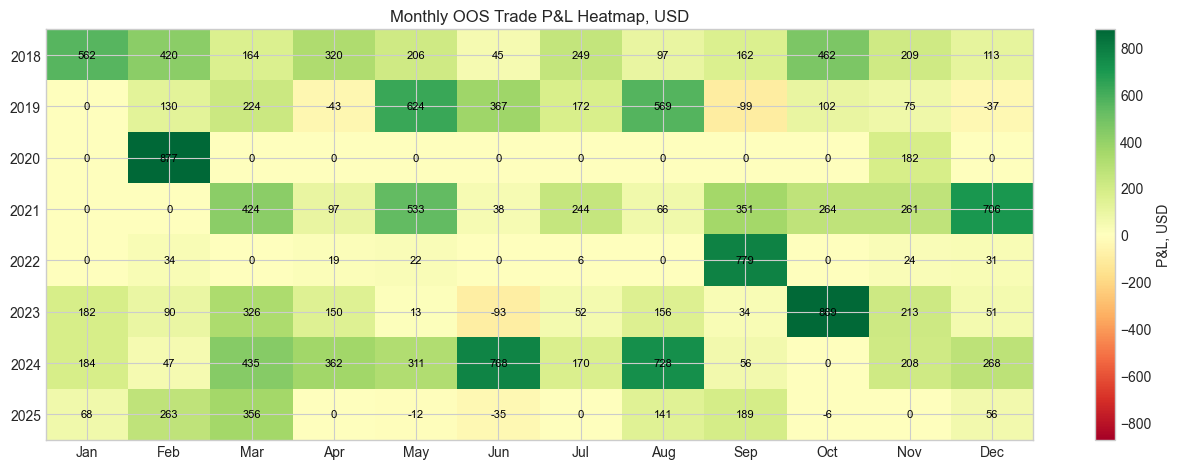

In [26]:
if filtered_trades.empty:
    print('No trades found.')
else:
    m = filtered_trades.copy()
    m['exit_date'] = pd.to_datetime(m['exit_date'], errors='coerce')
    m = m.dropna(subset=['exit_date'])
    m['year'] = m['exit_date'].dt.year
    m['month'] = m['exit_date'].dt.month
    heat = m.pivot_table(index='year', columns='month', values='pnl', aggfunc='sum', fill_value=0.0)
    heat = heat.reindex(columns=range(1, 13), fill_value=0.0)
    fig, ax = plt.subplots(figsize=(13, max(3, 0.6 * len(heat))))
    vmax = max(abs(float(heat.min().min())), abs(float(heat.max().max())), 1.0)
    im = ax.imshow(heat.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_title('Monthly OOS Trade P&L Heatmap, USD')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f'{heat.iloc[i, j]:,.0f}', ha='center', va='center', fontsize=8, color='black')
    plt.colorbar(im, ax=ax, label='P&L, USD')
    plt.tight_layout()
    plt.show()


## Fold Drill-Down

In [27]:
if SELECTED_FOLD is None:
    print('Set SELECTED_FOLD near the top of the notebook to inspect one fold in detail.')
elif filtered_folds.empty:
    print(f'No fold {SELECTED_FOLD} found.')
else:
    display(Markdown(f'### Fold {SELECTED_FOLD} Summary'))
    display(filtered_folds.T)
    display(Markdown(f'### Fold {SELECTED_FOLD} Trades'))
    trade_cols = ['ticker', 'entry_date', 'exit_date', 'pnl', 'return_on_capital_pct', 'hold_days', 'exit_reason', 'entry_zscore', 'entry_pctile']
    display(filtered_trades[[c for c in trade_cols if c in filtered_trades.columns]].sort_values('exit_date').reset_index(drop=True))


Set SELECTED_FOLD near the top of the notebook to inspect one fold in detail.


## LLM Analysis Files

In [28]:
llm_json = RESULTS_DIR / 'llm_walk_forward_overview.json'
llm_prompt = RESULTS_DIR / 'llm_walk_forward_prompt.txt'
print('LLM JSON:  ', llm_json, 'exists=' + str(llm_json.exists()))
print('LLM prompt:', llm_prompt, 'exists=' + str(llm_prompt.exists()))
if llm_prompt.exists():
    display(Markdown('### Prompt Preview'))
    print(llm_prompt.read_text(encoding='utf-8')[:2000])


LLM JSON:   C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner\data\results\walk_forward\llm_walk_forward_overview.json exists=True
LLM prompt: C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner\data\results\walk_forward\llm_walk_forward_prompt.txt exists=True


### Prompt Preview

You are analyzing a walk-forward validation of a systematic long ATM calendar spread strategy.

Use `llm_walk_forward_overview.json` as the primary source. It contains the config snapshot, tested grid ranges, stitched out-of-sample metrics, fold-by-fold performance, selected scenarios/parameters, and trade breakdowns.

Please produce:
1. Executive summary of whether the current parameters appear robust or fragile.
2. Fold-by-fold diagnosis: which windows worked, which failed, and whether failures cluster by market period.
3. Parameter stability analysis: selected z-score, percentile, profit target, stop loss, max hold, slippage, and other selected values.
4. What went well, with evidence.
5. What should be tweaked next, with concrete candidate ranges.
6. Whether it is reasonable to proceed to harsher slippage tests or longer history tests.

Important context:
- Strategy: long ATM calendar spreads targeting term-structure mean reversion.
- Walk-forward source range: 2016-01-04 to 2026-0